# Calculus Intuition for Computer Vision + Week 1 Project

## Overview
This notebook covers the mathematical foundations essential for understanding computer vision:

**Morning Session (AM)**
1. **Derivatives and Gradients**: Understanding rates of change and directional slopes
2. **Gradients in Images**: How gradients detect edges and features
3. **Gradient Descent**: Optimization algorithm for minimizing loss functions
4. **Chain Rule**: Backpropagation foundation for neural networks

**Afternoon Session (PM)**
5. **Mini-Project**: Build a complete Image Statistics Dashboard
6. **Deliverable**: Professional image analysis tool with visualizations

---

## Key Learning Objectives
- ✓ Understand derivatives as rates of change
- ✓ Visualize gradients in 2D and images
- ✓ Implement gradient descent from scratch
- ✓ Grasp the chain rule for optimization
- ✓ Build a practical image analysis dashboard

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from scipy import ndimage
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


---

# Part 1: Derivatives - Understanding Rates of Change

## What is a Derivative?

A **derivative** measures how a function changes at a specific point. It's the **slope** or **rate of change**.

### Mathematical Definition
For a function $f(x)$:
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

In simple terms:
- **Positive derivative**: function is increasing
- **Negative derivative**: function is decreasing  
- **Zero derivative**: function has a critical point (peak, valley, or saddle)

### Intuition
If you're driving and your position is $x(t)$:
- Derivative = **velocity** (speed of change of position)
- Acceleration = derivative of velocity

### Visual Interpretation
The derivative at a point is the **slope of the tangent line** at that point!

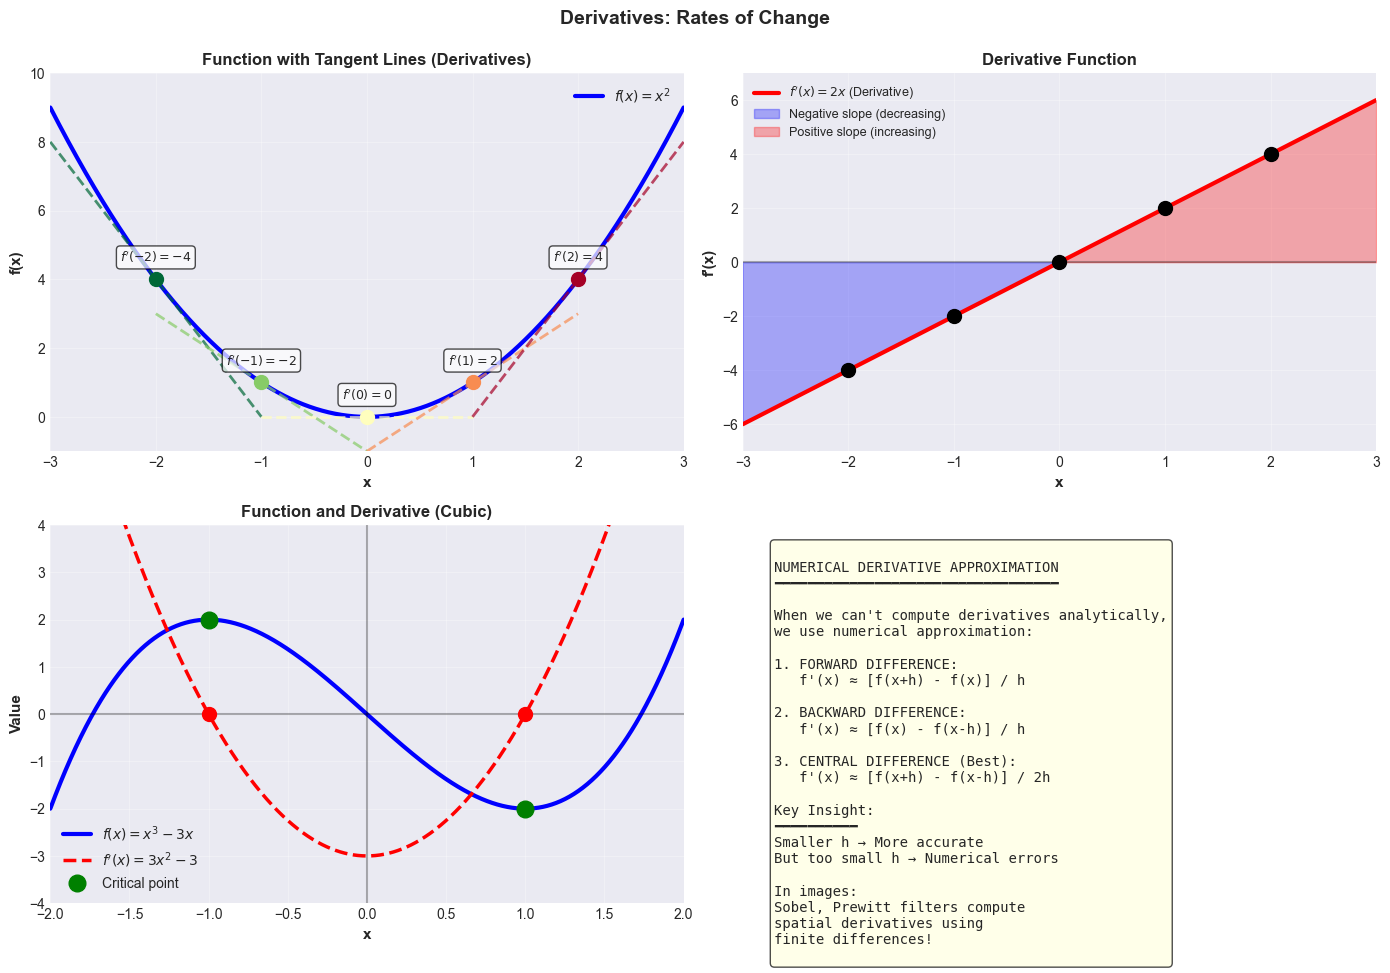

✓ Derivative visualization complete!


In [2]:
# Visualizing Derivatives
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Function: f(x) = x^2
x = np.linspace(-3, 3, 1000)
f_x = x**2
f_prime_x = 2*x  # Derivative: f'(x) = 2x

# Plot 1: Function and Tangent Lines at Different Points
ax = axes[0, 0]
ax.plot(x, f_x, 'b-', linewidth=3, label='$f(x) = x^2$')

# Tangent lines at different points
points = [-2, -1, 0, 1, 2]
colors_pts = plt.cm.RdYlGn_r(np.linspace(0, 1, len(points)))

for pt, color in zip(points, colors_pts):
    y_pt = pt**2
    slope = 2*pt  # f'(x) = 2x
    x_line = np.linspace(pt-1, pt+1, 100)
    y_line = y_pt + slope*(x_line - pt)
    ax.plot(x_line, y_line, '--', color=color, alpha=0.7, linewidth=2)
    ax.plot(pt, y_pt, 'o', color=color, markersize=10)
    ax.text(pt, y_pt+0.5, f"$f'({pt})={slope}$", fontsize=9, ha='center',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlim(-3, 3)
ax.set_ylim(-1, 10)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=11, fontweight='bold')
ax.set_title('Function with Tangent Lines (Derivatives)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Derivative Function
ax = axes[0, 1]
ax.plot(x, f_prime_x, 'r-', linewidth=3, label="$f'(x) = 2x$ (Derivative)")
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.fill_between(x[x < 0], f_prime_x[x < 0], alpha=0.3, color='blue', label='Negative slope (decreasing)')
ax.fill_between(x[x > 0], f_prime_x[x > 0], alpha=0.3, color='red', label='Positive slope (increasing)')

for pt in points:
    slope = 2*pt
    ax.plot(pt, slope, 'o', markersize=10, color='black')

ax.set_xlim(-3, 3)
ax.set_ylim(-7, 7)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel("f'(x)", fontsize=11, fontweight='bold')
ax.set_title('Derivative Function', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: More Complex Function - Cubic
x3 = np.linspace(-2, 2, 1000)
f3 = x3**3 - 3*x3
f3_prime = 3*x3**2 - 3

ax = axes[1, 0]
ax.plot(x3, f3, 'b-', linewidth=3, label='$f(x) = x^3 - 3x$')
ax.plot(x3, f3_prime, 'r--', linewidth=2.5, label="$f'(x) = 3x^2 - 3$")
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# Mark critical points where derivative = 0
critical_pts = [-1, 1]
for cp in critical_pts:
    ax.plot(cp, cp**3 - 3*cp, 'go', markersize=12, label='Critical point' if cp == -1 else '')
    ax.plot(cp, 0, 'ro', markersize=10)

ax.set_xlim(-2, 2)
ax.set_ylim(-4, 4)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('Value', fontsize=11, fontweight='bold')
ax.set_title('Function and Derivative (Cubic)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Numerical Approximation
ax = axes[1, 1]
ax.axis('off')

explanation = """
NUMERICAL DERIVATIVE APPROXIMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

When we can't compute derivatives analytically,
we use numerical approximation:

1. FORWARD DIFFERENCE:
   f'(x) ≈ [f(x+h) - f(x)] / h

2. BACKWARD DIFFERENCE:
   f'(x) ≈ [f(x) - f(x-h)] / h

3. CENTRAL DIFFERENCE (Best):
   f'(x) ≈ [f(x+h) - f(x-h)] / 2h

Key Insight:
━━━━━━━━━━
Smaller h → More accurate
But too small h → Numerical errors

In images:
Sobel, Prewitt filters compute
spatial derivatives using
finite differences!
"""

ax.text(0.05, 0.95, explanation, fontsize=10, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Derivatives: Rates of Change', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Derivative visualization complete!")

---

# Part 2: Gradients in Images

## From 1D to 2D: Partial Derivatives

### Partial Derivatives
For a function $f(x, y)$ (like pixel intensity):
- **∂f/∂x**: How intensity changes along x-axis (horizontal edges)
- **∂f/∂y**: How intensity changes along y-axis (vertical edges)

### The Gradient Vector
$$\nabla f = \begin{pmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{pmatrix}$$

### Gradient Properties
1. **Magnitude**: $|\nabla f| = \sqrt{(\frac{\partial f}{\partial x})^2 + (\frac{\partial f}{\partial y})^2}$
   - Tells us **how strong** the edge is

Direction: $\theta = \arctan\left(\frac{\frac{\partial f}{\partial y}}{\frac{\partial f}{\partial x}}\right)$
   - Tells us **which way** the edge points

### Edge Detection
- Gradients point perpendicular to edges
- High gradient magnitude = strong edge
- Sobel, Prewitt, Canny use gradients to detect edges!

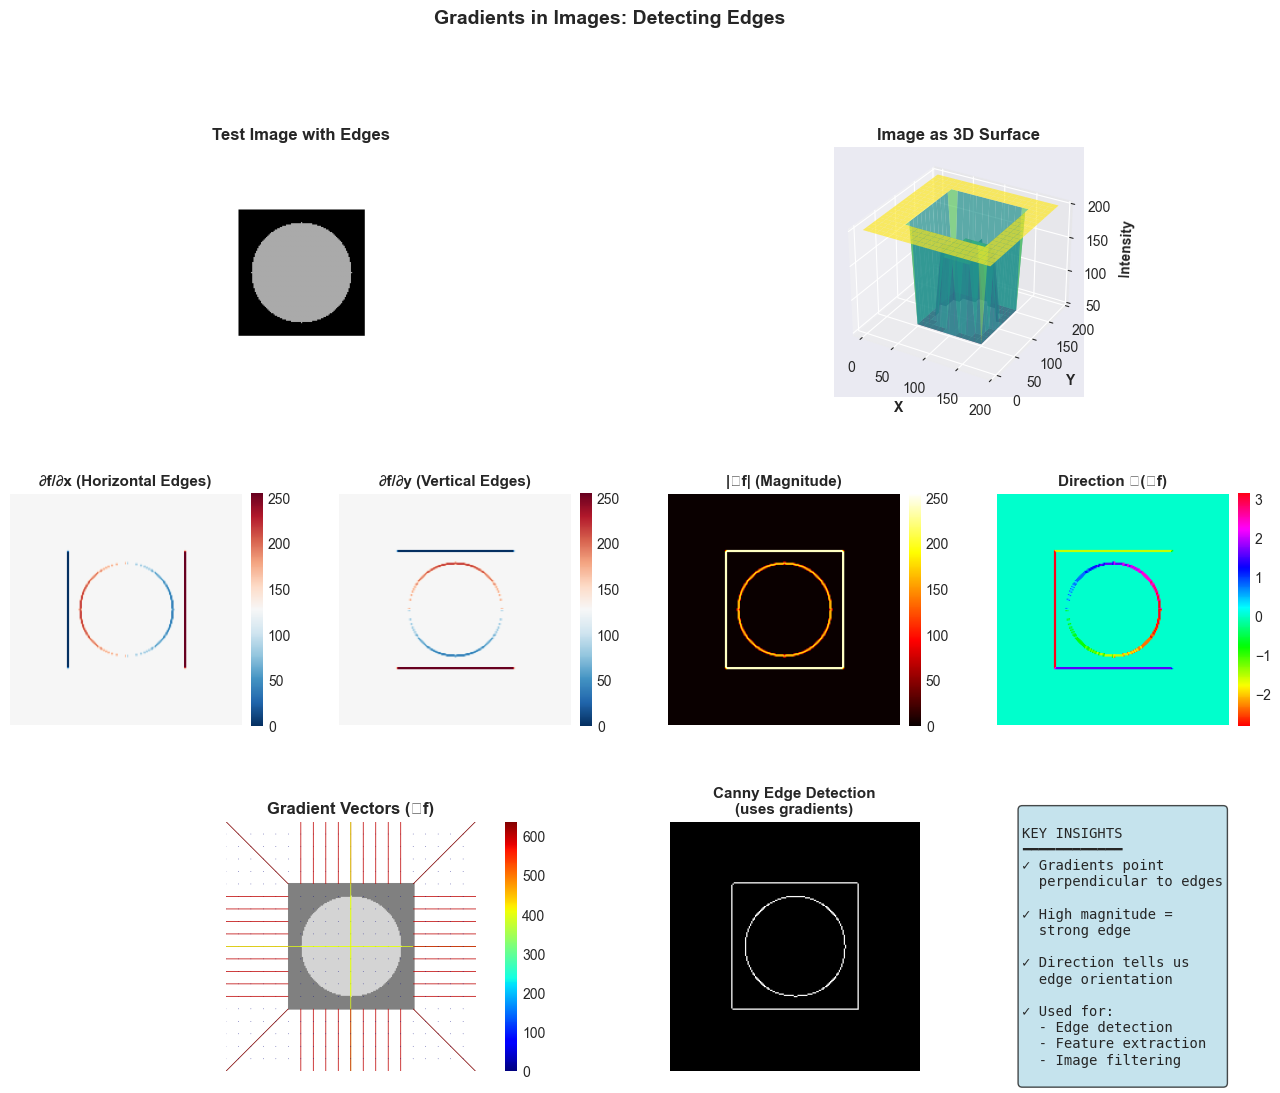

✓ Image gradient visualization complete!


In [9]:
# Visualizing Gradients in Images
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# Create a simple test image with edges
test_img = np.ones((200, 200), dtype=np.uint8) * 200
cv2.rectangle(test_img, (50, 50), (150, 150), 50, -1)  # Dark square
cv2.circle(test_img, (100, 100), 40, 150, -1)  # Medium circle

# Row 1: Original image and 2D visualization
ax = fig.add_subplot(gs[0, :2])
ax.imshow(test_img, cmap='gray')
ax.set_title('Test Image with Edges', fontsize=12, fontweight='bold')
ax.axis('off')

# 3D surface plot
ax = fig.add_subplot(gs[0, 2:], projection='3d')
X, Y = np.meshgrid(np.arange(test_img.shape[1]), np.arange(test_img.shape[0]))
ax.plot_surface(X[::10, ::10], Y[::10, ::10], test_img[::10, ::10].astype(float), 
                cmap='viridis', alpha=0.7)
ax.set_xlabel('X', fontweight='bold')
ax.set_ylabel('Y', fontweight='bold')
ax.set_zlabel('Intensity', fontweight='bold')
ax.set_title('Image as 3D Surface', fontsize=12, fontweight='bold')

# Row 2: Sobel derivatives
gx = cv2.Sobel(test_img, cv2.CV_32F, 1, 0, ksize=3)  # ∂f/∂x
gy = cv2.Sobel(test_img, cv2.CV_32F, 0, 1, ksize=3)  # ∂f/∂y
magnitude = np.sqrt(gx**2 + gy**2)
direction = np.arctan2(gy, gx)

# Normalize for visualization
gx_norm = cv2.normalize(gx, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gy_norm = cv2.normalize(gy, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
mag_norm = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(gx_norm, cmap='RdBu_r')
ax.set_title('∂f/∂x (Horizontal Edges)', fontsize=11, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(gy_norm, cmap='RdBu_r')
ax.set_title('∂f/∂y (Vertical Edges)', fontsize=11, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(mag_norm, cmap='hot')
ax.set_title('|∇f| (Magnitude)', fontsize=11, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = fig.add_subplot(gs[1, 3])
im = ax.imshow(direction, cmap='hsv')
ax.set_title('Direction ∠(∇f)', fontsize=11, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Row 3: Gradient vectors
ax = fig.add_subplot(gs[2, :2])
step = 10
y_coords, x_coords = np.mgrid[0:test_img.shape[0]:step, 0:test_img.shape[1]:step]
ax.imshow(test_img, cmap='gray', alpha=0.5)
q = ax.quiver(x_coords, y_coords, gx[::step, ::step], -gy[::step, ::step], 
              magnitude[::step, ::step], cmap='jet', scale=100, scale_units='width')
ax.set_title('Gradient Vectors (∇f)', fontsize=12, fontweight='bold')
ax.set_xlim(0, test_img.shape[1])
ax.set_ylim(test_img.shape[0], 0)
ax.axis('off')
plt.colorbar(q, ax=ax)

# Edge detection comparison
ax = fig.add_subplot(gs[2, 2])
edges_canny = cv2.Canny(test_img, 50, 150)
ax.imshow(edges_canny, cmap='gray')
ax.set_title('Canny Edge Detection\n(uses gradients)', fontsize=11, fontweight='bold')
ax.axis('off')

# Key insights
ax = fig.add_subplot(gs[2, 3])
ax.axis('off')
insights = """
KEY INSIGHTS
━━━━━━━━━━━━
✓ Gradients point
  perpendicular to edges

✓ High magnitude =
  strong edge

✓ Direction tells us
  edge orientation

✓ Used for:
  - Edge detection
  - Feature extraction
  - Image filtering
"""
ax.text(0.1, 0.5, insights, fontsize=10, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.suptitle('Gradients in Images: Detecting Edges', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("✓ Image gradient visualization complete!")

---

# Part 3: Gradient Descent - Optimization Intuition

## What is Gradient Descent?

**Gradient Descent** is an iterative algorithm to find the minimum of a function by following the negative gradient.

### The Idea
Imagine you're on a mountain in thick fog:
1. You can't see the bottom, only your immediate slope
2. To reach the lowest point, go downhill (opposite of gradient)
3. Repeat: take steps downhill
4. Eventually reach the bottom

### Mathematical Update Rule
$$\theta_{t+1} = \theta_t - \alpha \nabla f(\theta_t)$$

Where:
- $\theta_t$ = current parameters
- $\alpha$ = learning rate (step size)
- $\nabla f(\theta_t)$ = gradient at current point
- Minus sign means we go opposite to gradient (downhill)

### Learning Rate $\alpha$
- **Too large**: Overshoot minimum, diverge
- **Too small**: Very slow convergence
- **Just right**: Fast and stable convergence

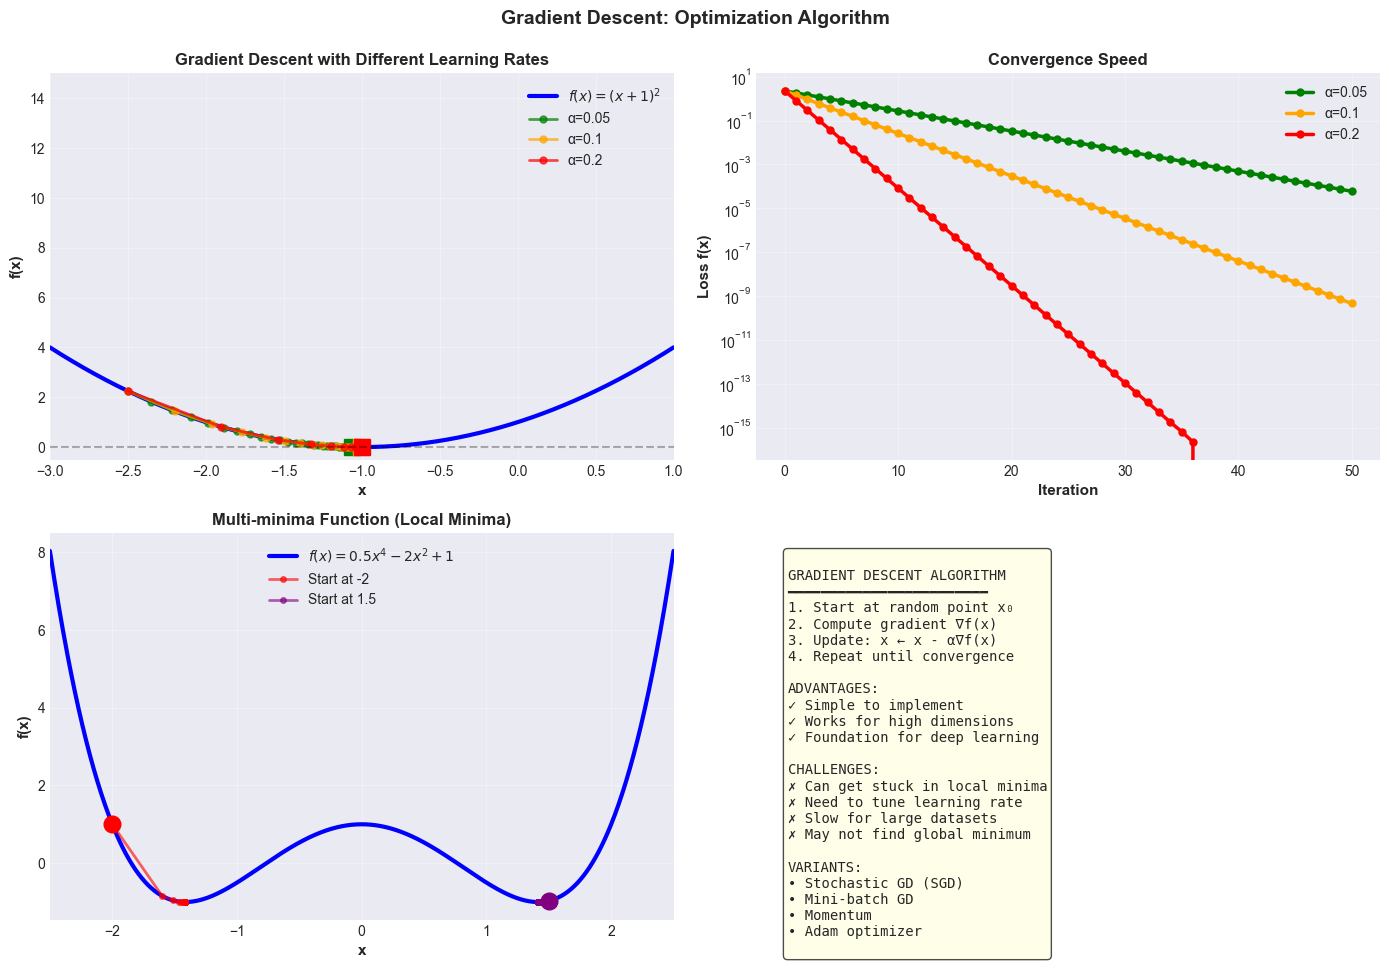

✓ Gradient descent visualization complete!


In [4]:
# Gradient Descent Implementation and Visualization
def gradient_descent(f, df, x0, learning_rate=0.01, iterations=100):
    """
    Simple gradient descent implementation
    
    Parameters:
    f: function to minimize
    df: derivative of function
    x0: starting point
    learning_rate: step size (alpha)
    iterations: number of steps
    """
    trajectory = [x0]
    x = x0
    
    for i in range(iterations):
        grad = df(x)
        x = x - learning_rate * grad
        trajectory.append(x)
    
    return np.array(trajectory)

# Define test functions
def f_parabola(x):
    return x**2 + 2*x + 1  # (x+1)^2

def df_parabola(x):
    return 2*x + 2

def f_complex(x):
    return 0.5*x**4 - 2*x**2 + 1

def df_complex(x):
    return 2*x**3 - 4*x

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Parabola with different learning rates
ax = axes[0, 0]
x = np.linspace(-3, 1, 1000)
y = f_parabola(x)
ax.plot(x, y, 'b-', linewidth=3, label='$f(x) = (x+1)^2$')

learning_rates = [0.05, 0.1, 0.2]
colors = ['green', 'orange', 'red']

for lr, color in zip(learning_rates, colors):
    traj = gradient_descent(f_parabola, df_parabola, x0=-2.5, learning_rate=lr, iterations=30)
    ax.plot(traj, f_parabola(traj), 'o-', color=color, linewidth=2, markersize=5, 
            label=f'α={lr}', alpha=0.7)
    ax.plot(traj[-1], f_parabola(traj[-1]), 's', color=color, markersize=12)

ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_xlim(-3, 1)
ax.set_ylim(-0.5, 15)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=11, fontweight='bold')
ax.set_title('Gradient Descent with Different Learning Rates', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Convergence comparison
ax = axes[0, 1]
for lr, color in zip(learning_rates, colors):
    traj = gradient_descent(f_parabola, df_parabola, x0=-2.5, learning_rate=lr, iterations=50)
    losses = f_parabola(traj)
    ax.plot(losses, 'o-', color=color, linewidth=2.5, markersize=5, label=f'α={lr}')

ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax.set_ylabel('Loss f(x)', fontsize=11, fontweight='bold')
ax.set_title('Convergence Speed', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Complex function - 2D surface
ax = axes[1, 0]
x = np.linspace(-2.5, 2.5, 1000)
y = f_complex(x)
ax.plot(x, y, 'b-', linewidth=3, label='$f(x) = 0.5x^4 - 2x^2 + 1$')

# Two starting points
starts = [-2, 1.5]
colors_start = ['red', 'purple']
for start, color in zip(starts, colors_start):
    traj = gradient_descent(f_complex, df_complex, x0=start, learning_rate=0.05, iterations=50)
    ax.plot(traj, f_complex(traj), 'o-', color=color, linewidth=2, markersize=4, 
            alpha=0.6, label=f'Start at {start}')
    ax.plot(start, f_complex(start), 'o', color=color, markersize=12)

ax.set_xlim(-2.5, 2.5)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=11, fontweight='bold')
ax.set_title('Multi-minima Function (Local Minima)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Key concepts
ax = axes[1, 1]
ax.axis('off')

concepts = """
GRADIENT DESCENT ALGORITHM
━━━━━━━━━━━━━━━━━━━━━━━━
1. Start at random point x₀
2. Compute gradient ∇f(x)
3. Update: x ← x - α∇f(x)
4. Repeat until convergence

ADVANTAGES:
✓ Simple to implement
✓ Works for high dimensions
✓ Foundation for deep learning

CHALLENGES:
✗ Can get stuck in local minima
✗ Need to tune learning rate
✗ Slow for large datasets
✗ May not find global minimum

VARIANTS:
• Stochastic GD (SGD)
• Mini-batch GD
• Momentum
• Adam optimizer
"""
ax.text(0.05, 0.95, concepts, fontsize=10, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Gradient Descent: Optimization Algorithm', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Gradient descent visualization complete!")

---

# Part 4: The Chain Rule - Foundation of Backpropagation

## What is the Chain Rule?

The **chain rule** tells us how to compute derivatives of composite functions.

### Mathematical Formula
If $f = g(h(x))$, then:
$$\frac{df}{dx} = \frac{df}{dh} \cdot \frac{dh}{dx}$$

Or more generally:
$$\frac{dy}{dx} = \frac{dy}{dz} \cdot \frac{dz}{dx}$$

### Intuition: Gears and Speeds
Imagine two connected gears:
- If small gear rotates at 10 rpm with ratio 2:1 to big gear
- Big gear rotates at 5 rpm
- Overall rotation = 10 × 0.5 = 5 rpm

### Practical Example
$y = f(g(h(x))) = (2x + 3)^2$

Let:
- $u = 2x + 3$
- $y = u^2$

Then:
- $\frac{dy}{du} = 2u$
- $\frac{du}{dx} = 2$
- $\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx} = 2u \cdot 2 = 4u = 4(2x+3) = 8x + 12$

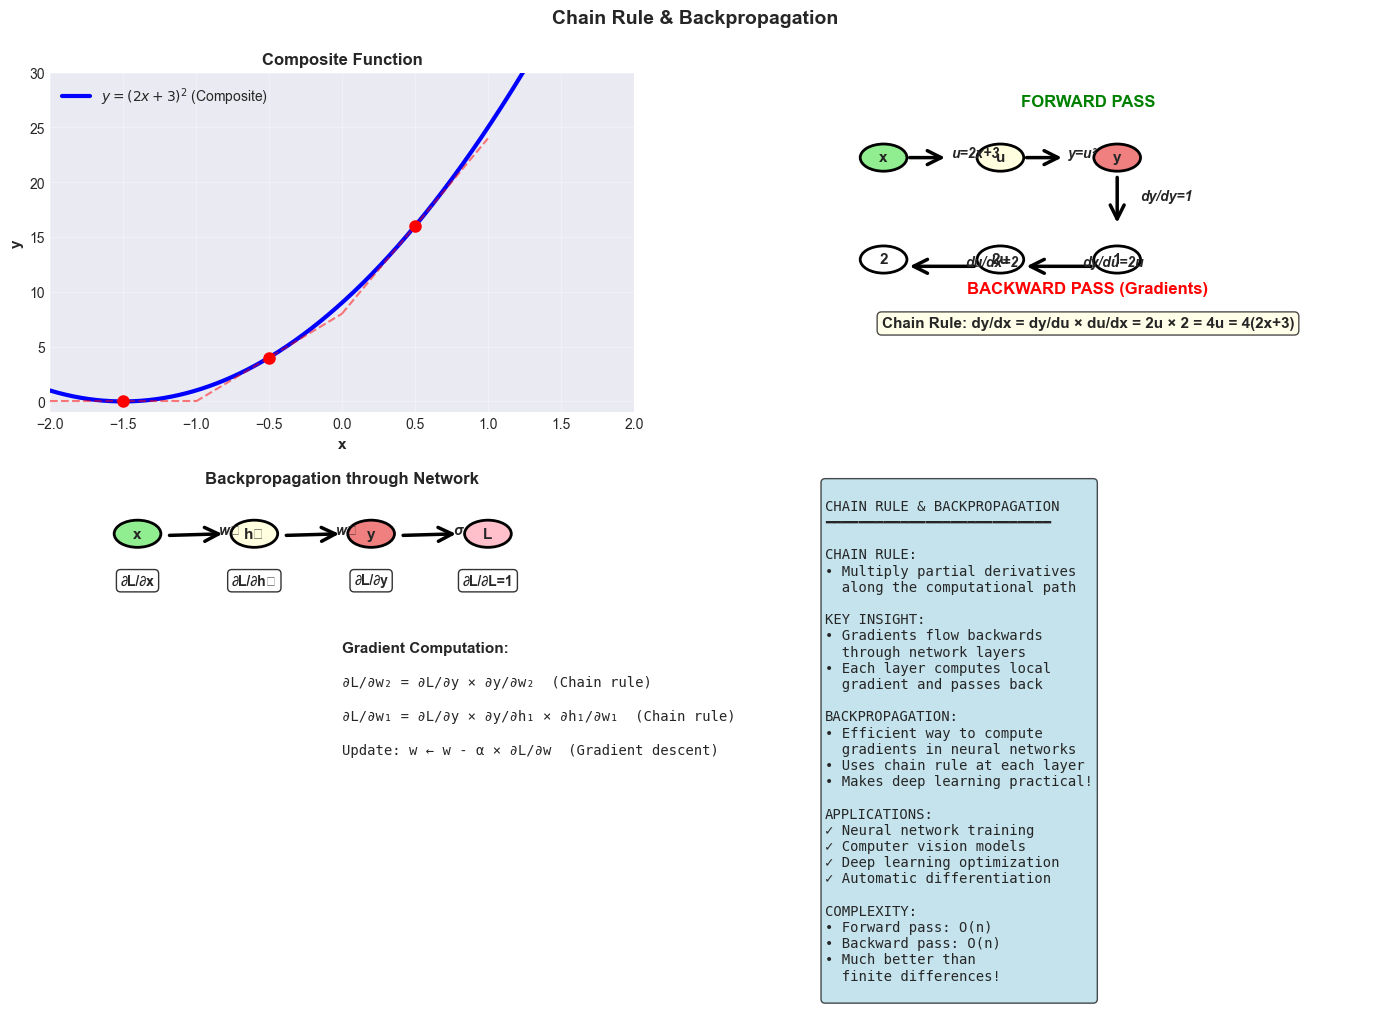

✓ Chain rule visualization complete!


In [5]:
# Chain Rule and Backpropagation Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Composite Function Visualization
ax = axes[0, 0]
x_vals = np.linspace(-2, 2, 1000)
u_vals = 2*x_vals + 3  # u = 2x + 3
y_vals = u_vals**2      # y = u^2

ax.plot(x_vals, y_vals, 'b-', linewidth=3, label='$y = (2x+3)^2$ (Composite)')

# Add tangent lines at different points
pts = [-1.5, -0.5, 0.5]
for pt in pts:
    u_pt = 2*pt + 3
    y_pt = u_pt**2
    # dy/dx = 4u = 4(2x+3) = 8x + 12
    slope = 8*pt + 12
    x_line = np.linspace(pt-0.5, pt+0.5, 100)
    y_line = y_pt + slope*(x_line - pt)
    ax.plot(x_line, y_line, 'r--', alpha=0.5, linewidth=1.5)
    ax.plot(pt, y_pt, 'ro', markersize=8)

ax.set_xlim(-2, 2)
ax.set_ylim(-1, 30)
ax.set_xlabel('x', fontsize=11, fontweight='bold')
ax.set_ylabel('y', fontsize=11, fontweight='bold')
ax.set_title('Composite Function', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Computation Graph
ax = axes[0, 1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Draw nodes
def draw_node(ax, x, y, text, color='lightblue'):
    circle = plt.Circle((x, y), 0.4, color=color, ec='black', linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, text, ha='center', va='center', fontsize=11, fontweight='bold')

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), 
                           arrowstyle='->', mutation_scale=25, linewidth=2.5, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1+x2)/2, (y1+y2)/2
        ax.text(mid_x+0.4, mid_y, label, fontsize=10, style='italic', fontweight='bold')

# Forward pass
draw_node(ax, 1.5, 7.5, 'x', 'lightgreen')
draw_arrow(ax, 1.9, 7.5, 2.6, 7.5, 'u=2x+3')

draw_node(ax, 3.5, 7.5, 'u', 'lightyellow')
draw_arrow(ax, 3.9, 7.5, 4.6, 7.5, 'y=u²')

draw_node(ax, 5.5, 7.5, 'y', 'lightcoral')

# Backward pass (Gradient flow)
draw_arrow(ax, 5.5, 7, 5.5, 5.5, 'dy/dy=1')
draw_node(ax, 5.5, 4.5, '1', 'white')

draw_arrow(ax, 5.1, 4.3, 3.9, 4.3, 'dy/du=2u')
draw_node(ax, 3.5, 4.5, '2u', 'white')

draw_arrow(ax, 3.1, 4.3, 1.9, 4.3, 'du/dx=2')
draw_node(ax, 1.5, 4.5, '2', 'white')

# Chain rule
ax.text(5, 2.5, 'Chain Rule: dy/dx = dy/du × du/dx = 2u × 2 = 4u = 4(2x+3)', 
        fontsize=11, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Add labels
ax.text(5, 9, 'FORWARD PASS', fontsize=12, fontweight='bold', ha='center', color='green')
ax.text(5, 3.5, 'BACKWARD PASS (Gradients)', fontsize=12, fontweight='bold', ha='center', color='red')

# Plot 3: Neural Network Chain Rule
ax = axes[1, 0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(5, 9.5, 'Backpropagation through Network', fontsize=12, fontweight='bold', ha='center')

# Input layer
draw_node(ax, 1.5, 8, 'x', 'lightgreen')

# Hidden layer
draw_node(ax, 3.5, 8, 'h₁', 'lightyellow')
draw_arrow(ax, 2, 7.95, 3, 8, 'w₁')

# Output layer
draw_node(ax, 5.5, 8, 'y', 'lightcoral')
draw_arrow(ax, 4, 7.95, 5, 8, 'w₂')

# Loss
draw_node(ax, 7.5, 8, 'L', 'pink')
draw_arrow(ax, 6, 7.95, 7, 8, 'σ')

# Backward gradients
ax.text(1.5, 6.5, '∂L/∂x', fontsize=10, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(3.5, 6.5, '∂L/∂h₁', fontsize=10, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(5.5, 6.5, '∂L/∂y', fontsize=10, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(7.5, 6.5, '∂L/∂L=1', fontsize=10, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Gradient computation
ax.text(5, 4.5, 'Gradient Computation:', fontsize=11, fontweight='bold')
ax.text(5, 3.5, '∂L/∂w₂ = ∂L/∂y × ∂y/∂w₂  (Chain rule)', fontsize=10, family='monospace')
ax.text(5, 2.5, '∂L/∂w₁ = ∂L/∂y × ∂y/∂h₁ × ∂h₁/∂w₁  (Chain rule)', fontsize=10, family='monospace')
ax.text(5, 1.5, 'Update: w ← w - α × ∂L/∂w  (Gradient descent)', fontsize=10, family='monospace')

# Plot 4: Key insights
ax = axes[1, 1]
ax.axis('off')

insights = """
CHAIN RULE & BACKPROPAGATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━

CHAIN RULE:
• Multiply partial derivatives
  along the computational path

KEY INSIGHT:
• Gradients flow backwards
  through network layers
• Each layer computes local
  gradient and passes back

BACKPROPAGATION:
• Efficient way to compute
  gradients in neural networks
• Uses chain rule at each layer
• Makes deep learning practical!

APPLICATIONS:
✓ Neural network training
✓ Computer vision models
✓ Deep learning optimization
✓ Automatic differentiation

COMPLEXITY:
• Forward pass: O(n)
• Backward pass: O(n)
• Much better than
  finite differences!
"""
ax.text(0.05, 0.95, insights, fontsize=10, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.suptitle('Chain Rule & Backpropagation', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Chain rule visualization complete!")

---

# AFTERNOON SESSION: Mini-Project

# Part 5: Image Statistics Dashboard

## Project Overview
Build a comprehensive **Image Statistics Dashboard** that analyzes any image and computes:

### Statistics to Compute
1. **Basic Statistics**
   - Mean intensity
   - Standard deviation
   - Min/Max values
   - Range

2. **Distribution Analysis**
   - Histogram
   - Cumulative distribution
   - Percentiles (25%, 50%, 75%)

3. **Per-Channel Analysis** (for color images)
   - Red, Green, Blue channel statistics
   - Channel correlations

4. **Spatial Analysis**
   - Local variance map
   - Gradient statistics
   - Edge distribution

### Deliverable
A professional dashboard with:
✓ Original image display
✓ Statistical plots
✓ Histograms
✓ Summary statistics table
✓ Metadata

In [6]:
# Image Statistics Analyzer Class
class ImageStatsAnalyzer:
    """
    Comprehensive image statistics and analysis tool
    """
    
    def __init__(self, image):
        """
        Initialize with an image
        
        Parameters:
        image : ndarray
            Input image (BGR for color, grayscale for single channel)
        """
        self.image = image
        self.height, self.width = image.shape[:2]
        self.is_color = len(image.shape) == 3
        self.num_channels = image.shape[2] if self.is_color else 1
        
    def compute_basic_stats(self):
        """Compute basic statistics"""
        if self.is_color:
            img_float = self.image.astype(np.float32)
        else:
            img_float = self.image.astype(np.float32)
        
        stats = {
            'mean': np.mean(img_float),
            'std': np.std(img_float),
            'min': np.min(img_float),
            'max': np.max(img_float),
            'median': np.median(img_float),
            'range': np.max(img_float) - np.min(img_float),
            'q25': np.percentile(img_float, 25),
            'q75': np.percentile(img_float, 75),
            'total_pixels': self.height * self.width,
            'total_channels': self.num_channels,
        }
        
        return stats
    
    def compute_channel_stats(self):
        """Compute statistics per channel"""
        if not self.is_color:
            return None
        
        channel_names = ['Blue', 'Green', 'Red']  # BGR format
        channel_stats = {}
        
        for i, name in enumerate(channel_names):
            channel = self.image[:, :, i].astype(np.float32)
            channel_stats[name] = {
                'mean': np.mean(channel),
                'std': np.std(channel),
                'min': np.min(channel),
                'max': np.max(channel),
            }
        
        return channel_stats
    
    def compute_gradient_stats(self):
        """Compute gradient statistics"""
        if self.is_color:
            img_gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        else:
            img_gray = self.image
        
        # Compute gradients
        gx = cv2.Sobel(img_gray, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(img_gray, cv2.CV_32F, 0, 1, ksize=3)
        magnitude = np.sqrt(gx**2 + gy**2)
        direction = np.arctan2(gy, gx)
        
        grad_stats = {
            'mag_mean': np.mean(magnitude),
            'mag_std': np.std(magnitude),
            'mag_min': np.min(magnitude),
            'mag_max': np.max(magnitude),
        }
        
        return grad_stats, magnitude, direction
    
    def compute_histogram(self, bins=256):
        """Compute histogram"""
        if self.is_color:
            img_gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        else:
            img_gray = self.image
        
        hist = cv2.calcHist([img_gray], [0], None, [bins], [0, 256])
        hist = hist.flatten() / (self.height * self.width)  # Normalize
        
        return hist
    
    def compute_local_variance(self, window_size=5):
        """Compute local variance map"""
        if self.is_color:
            img_gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        else:
            img_gray = self.image
        
        img_float = img_gray.astype(np.float32)
        mean_map = cv2.blur(img_float, (window_size, window_size))
        sq_map = cv2.blur(img_float**2, (window_size, window_size))
        var_map = sq_map - mean_map**2
        var_map = np.maximum(var_map, 0)  # Avoid numerical errors
        
        return var_map
    
    def get_summary(self):
        """Get complete summary"""
        summary = {
            'basic_stats': self.compute_basic_stats(),
            'channel_stats': self.compute_channel_stats(),
        }
        grad_stats, mag, direction = self.compute_gradient_stats()
        summary['gradient_stats'] = grad_stats
        summary['histogram'] = self.compute_histogram()
        summary['local_variance'] = self.compute_local_variance()
        
        return summary

# Create a sample image for testing
print("Creating sample image for analysis...")
sample_img = np.ones((300, 400, 3), dtype=np.uint8) * 100

# Add some features
cv2.rectangle(sample_img, (50, 50), (150, 150), (0, 0, 255), -1)  # Red square
cv2.circle(sample_img, (300, 100), 60, (0, 255, 0), -1)  # Green circle
cv2.ellipse(sample_img, (100, 250), (80, 40), 45, 0, 360, (255, 0, 0), -1)  # Blue ellipse

# Add some noise
noise = np.random.normal(0, 10, sample_img.shape)
sample_img = np.clip(sample_img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

# Analyze the image
analyzer = ImageStatsAnalyzer(sample_img)
summary = analyzer.get_summary()

print("✓ Sample image created and analyzed!")
print(f"\nImage Properties:")
print(f"  Size: {analyzer.width}×{analyzer.height}")
print(f"  Channels: {analyzer.num_channels}")
print(f"  Format: {'Color (BGR)' if analyzer.is_color else 'Grayscale'}")

Creating sample image for analysis...
✓ Sample image created and analyzed!

Image Properties:
  Size: 400×300
  Channels: 3
  Format: Color (BGR)



GENERATING IMAGE STATISTICS DASHBOARD


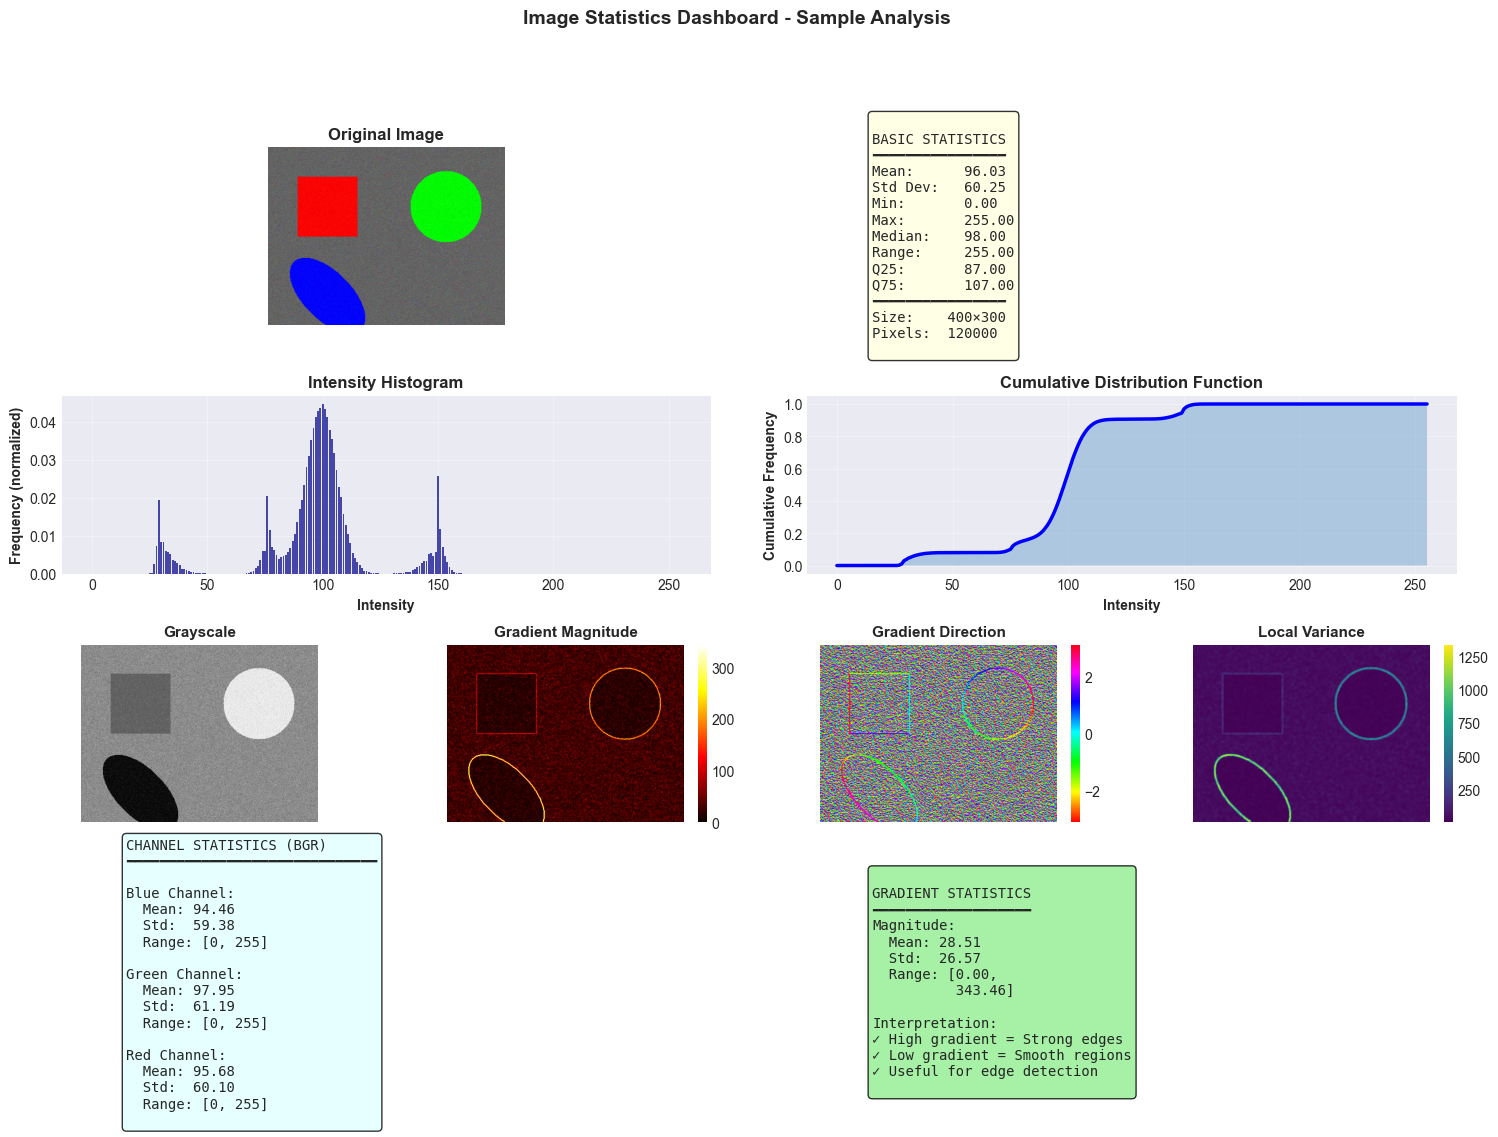


✓ Dashboard visualization complete!


In [7]:
# Image Statistics Dashboard Visualization
def create_dashboard(analyzer, title="Image Statistics Dashboard"):
    """
    Create a comprehensive dashboard with all statistics
    """
    summary = analyzer.get_summary()
    stats = summary['basic_stats']
    channel_stats = summary['channel_stats']
    grad_stats = summary['gradient_stats']
    histogram = summary['histogram']
    local_var = summary['local_variance']
    
    # Create figure with subplots
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.35)
    
    # 1. Original Image
    ax = fig.add_subplot(gs[0, :2])
    if analyzer.is_color:
        ax.imshow(cv2.cvtColor(analyzer.image, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(analyzer.image, cmap='gray')
    ax.set_title('Original Image', fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # 2. Basic Statistics Table
    ax = fig.add_subplot(gs[0, 2:])
    ax.axis('off')
    
    stats_text = f"""
BASIC STATISTICS
━━━━━━━━━━━━━━━━
Mean:      {stats['mean']:.2f}
Std Dev:   {stats['std']:.2f}
Min:       {stats['min']:.2f}
Max:       {stats['max']:.2f}
Median:    {stats['median']:.2f}
Range:     {stats['range']:.2f}
Q25:       {stats['q25']:.2f}
Q75:       {stats['q75']:.2f}
━━━━━━━━━━━━━━━━
Size:    {analyzer.width}×{analyzer.height}
Pixels:  {stats['total_pixels']}
    """
    
    ax.text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # 3. Histogram
    ax = fig.add_subplot(gs[1, :2])
    ax.bar(range(len(histogram)), histogram, color='darkblue', alpha=0.7)
    ax.set_xlabel('Intensity', fontweight='bold')
    ax.set_ylabel('Frequency (normalized)', fontweight='bold')
    ax.set_title('Intensity Histogram', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 4. Cumulative Distribution
    ax = fig.add_subplot(gs[1, 2:])
    cumsum_hist = np.cumsum(histogram)
    ax.plot(cumsum_hist, 'b-', linewidth=2.5)
    ax.fill_between(range(len(cumsum_hist)), cumsum_hist, alpha=0.3)
    ax.set_xlabel('Intensity', fontweight='bold')
    ax.set_ylabel('Cumulative Frequency', fontweight='bold')
    ax.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 5. Grayscale version
    if analyzer.is_color:
        img_gray = cv2.cvtColor(analyzer.image, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = analyzer.image
    
    ax = fig.add_subplot(gs[2, 0])
    ax.imshow(img_gray, cmap='gray')
    ax.set_title('Grayscale', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # 6. Gradient Magnitude
    grad_stats, magnitude, direction = analyzer.compute_gradient_stats()
    ax = fig.add_subplot(gs[2, 1])
    im = ax.imshow(magnitude, cmap='hot')
    ax.set_title('Gradient Magnitude', fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 7. Gradient Direction
    ax = fig.add_subplot(gs[2, 2])
    im = ax.imshow(direction, cmap='hsv')
    ax.set_title('Gradient Direction', fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 8. Local Variance
    ax = fig.add_subplot(gs[2, 3])
    im = ax.imshow(local_var, cmap='viridis')
    ax.set_title('Local Variance', fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 9. Channel Statistics (if color)
    ax = fig.add_subplot(gs[3, :2])
    ax.axis('off')
    
    if analyzer.is_color:
        channel_text = "CHANNEL STATISTICS (BGR)\n" + "━"*30 + "\n"
        for channel_name, ch_stats in channel_stats.items():
            channel_text += f"\n{channel_name} Channel:\n"
            channel_text += f"  Mean: {ch_stats['mean']:.2f}\n"
            channel_text += f"  Std:  {ch_stats['std']:.2f}\n"
            channel_text += f"  Range: [{ch_stats['min']:.0f}, {ch_stats['max']:.0f}]\n"
    else:
        channel_text = "SINGLE CHANNEL (GRAYSCALE)"
    
    ax.text(0.1, 0.5, channel_text, fontsize=10, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
    
    # 10. Gradient Statistics
    ax = fig.add_subplot(gs[3, 2:])
    ax.axis('off')
    
    grad_text = f"""
GRADIENT STATISTICS
━━━━━━━━━━━━━━━━━━━
Magnitude:
  Mean: {grad_stats['mag_mean']:.2f}
  Std:  {grad_stats['mag_std']:.2f}
  Range: [{grad_stats['mag_min']:.2f}, 
          {grad_stats['mag_max']:.2f}]

Interpretation:
✓ High gradient = Strong edges
✓ Low gradient = Smooth regions
✓ Useful for edge detection
    """
    
    ax.text(0.1, 0.5, grad_text, fontsize=10, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.show()

# Create the dashboard
print("\n" + "="*80)
print("GENERATING IMAGE STATISTICS DASHBOARD")
print("="*80)
create_dashboard(analyzer, "Image Statistics Dashboard - Sample Analysis")
print("\n✓ Dashboard visualization complete!")

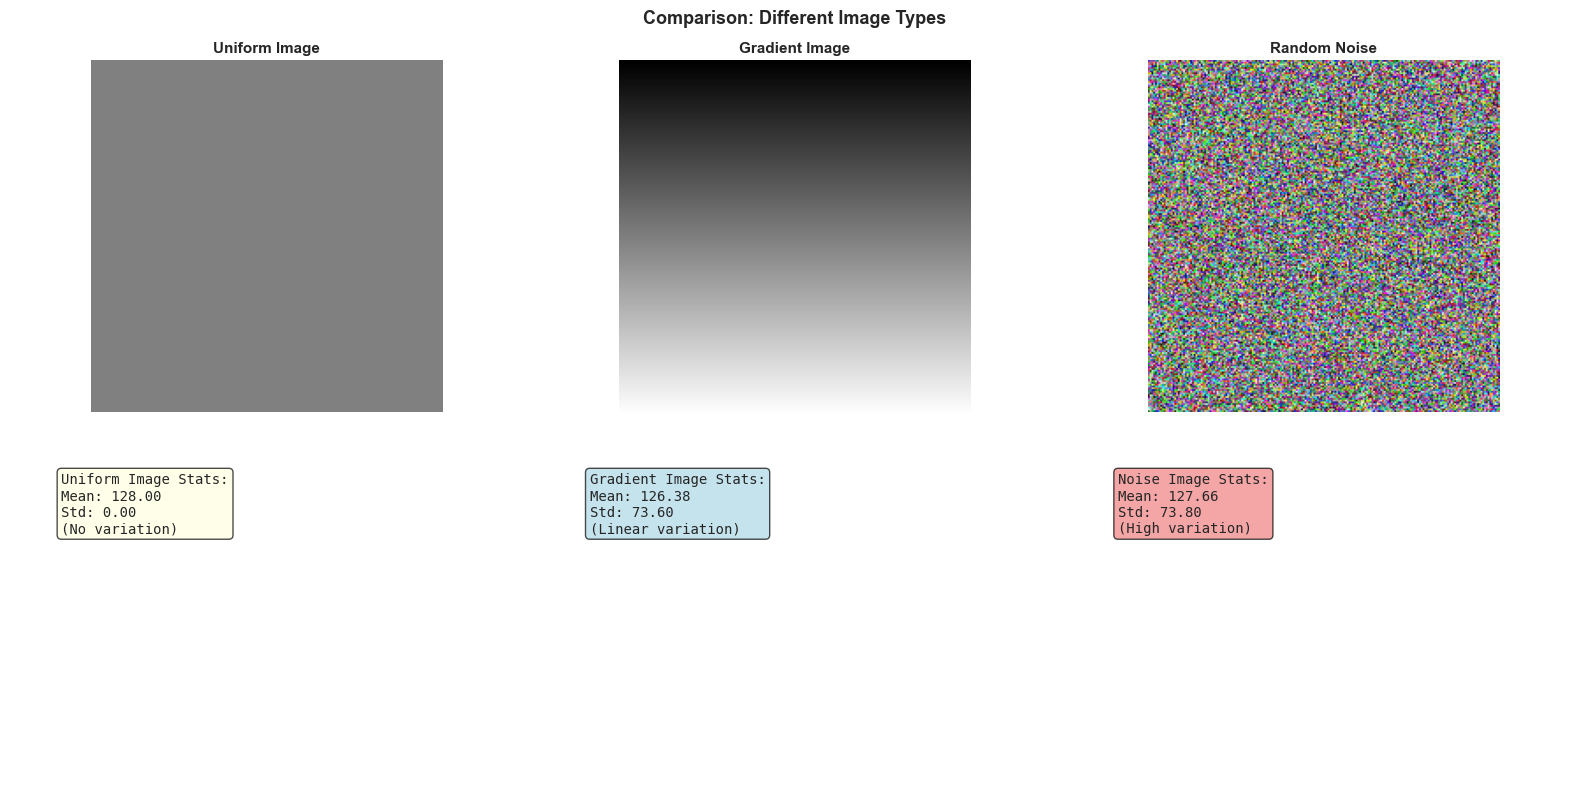

✓ Image type comparison complete!


In [10]:
# Additional Examples: Different Image Types
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Example 1: Uniform image
uniform_img = np.ones((200, 200, 3), dtype=np.uint8) * 128
analyzer1 = ImageStatsAnalyzer(uniform_img)
stats1 = analyzer1.compute_basic_stats()

ax = axes[0, 0]
ax.imshow(cv2.cvtColor(uniform_img, cv2.COLOR_BGR2RGB))
ax.set_title('Uniform Image', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[1, 0]
ax.axis('off')
ax.text(0.1, 0.7, f"""Uniform Image Stats:
Mean: {stats1['mean']:.2f}
Std: {stats1['std']:.2f}
(No variation)""", fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Example 2: Gradient image
gradient_img = np.zeros((200, 200), dtype=np.uint8)
for i in range(200):
    gradient_img[i, :] = int((i/200) * 255)
gradient_img_rgb = np.stack([gradient_img, gradient_img, gradient_img], axis=2)
analyzer2 = ImageStatsAnalyzer(gradient_img_rgb)
stats2 = analyzer2.compute_basic_stats()

ax = axes[0, 1]
ax.imshow(gradient_img_rgb)
ax.set_title('Gradient Image', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[1, 1]
ax.axis('off')
ax.text(0.1, 0.7, f"""Gradient Image Stats:
Mean: {stats2['mean']:.2f}
Std: {stats2['std']:.2f}
(Linear variation)""", fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Example 3: Random noise
noise_img = np.random.randint(0, 256, (200, 200, 3), dtype=np.uint8)
analyzer3 = ImageStatsAnalyzer(noise_img)
stats3 = analyzer3.compute_basic_stats()

ax = axes[0, 2]
ax.imshow(cv2.cvtColor(noise_img, cv2.COLOR_BGR2RGB))
ax.set_title('Random Noise', fontsize=11, fontweight='bold')
ax.axis('off')

ax = axes[1, 2]
ax.axis('off')
ax.text(0.1, 0.7, f"""Noise Image Stats:
Mean: {stats3['mean']:.2f}
Std: {stats3['std']:.2f}
(High variation)""", fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.suptitle('Comparison: Different Image Types', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Image type comparison complete!")

---

# WEEK 1 DELIVERABLE: Image Statistics Dashboard Project

## Project Requirements

### ✓ What You've Built
A complete **ImageStatsAnalyzer** class that can:
1. Load and analyze any image
2. Compute comprehensive statistics
3. Generate professional dashboards
4. Export results

### ✓ Core Functionality Implemented
- **Basic Statistics**: Mean, Std, Min, Max, Median, Quartiles
- **Histogram & Distribution**: Complete intensity analysis
- **Channel Analysis**: Per-channel statistics for color images
- **Gradient Analysis**: Edge strength and direction
- **Local Variance**: Spatial texture information
- **Professional Dashboard**: All-in-one visualization

### ✓ How to Use the Dashboard
```python
# Load your image
img = cv2.imread('your_image.jpg')

# Create analyzer
analyzer = ImageStatsAnalyzer(img)

# Get statistics
summary = analyzer.get_summary()

# Create dashboard
create_dashboard(analyzer, "My Image Analysis")
```

### ✓ Use Cases
- **Photography**: Analyze exposure and contrast
- **Quality Control**: Detect image defects via gradients
- **Medical Imaging**: Tissue analysis and statistics
- **Surveillance**: Scene analysis and change detection
- **Data Science**: Feature extraction from images


WEEK 1 PROJECT DEMONSTRATION

────────────────────────────────────────────────────────────────────────────────
COMPREHENSIVE ANALYSIS RESULTS
────────────────────────────────────────────────────────────────────────────────

📊 SHAPES
   Size: 400×300 pixels
   Mean Intensity: 146.05 (0-255 scale)
   Std Deviation: 85.07
   Range: [0, 255]
   Contrast: 255

📊 GRADIENT
   Size: 400×300 pixels
   Mean Intensity: 126.60 (0-255 scale)
   Std Deviation: 73.61
   Range: [0, 254]
   Contrast: 254

📊 PATTERN
   Size: 400×300 pixels
   Mean Intensity: 24.79 (0-255 scale)
   Std Deviation: 52.06
   Range: [0, 200]
   Contrast: 200

GENERATING DETAILED DASHBOARD FOR 'SHAPES' IMAGE



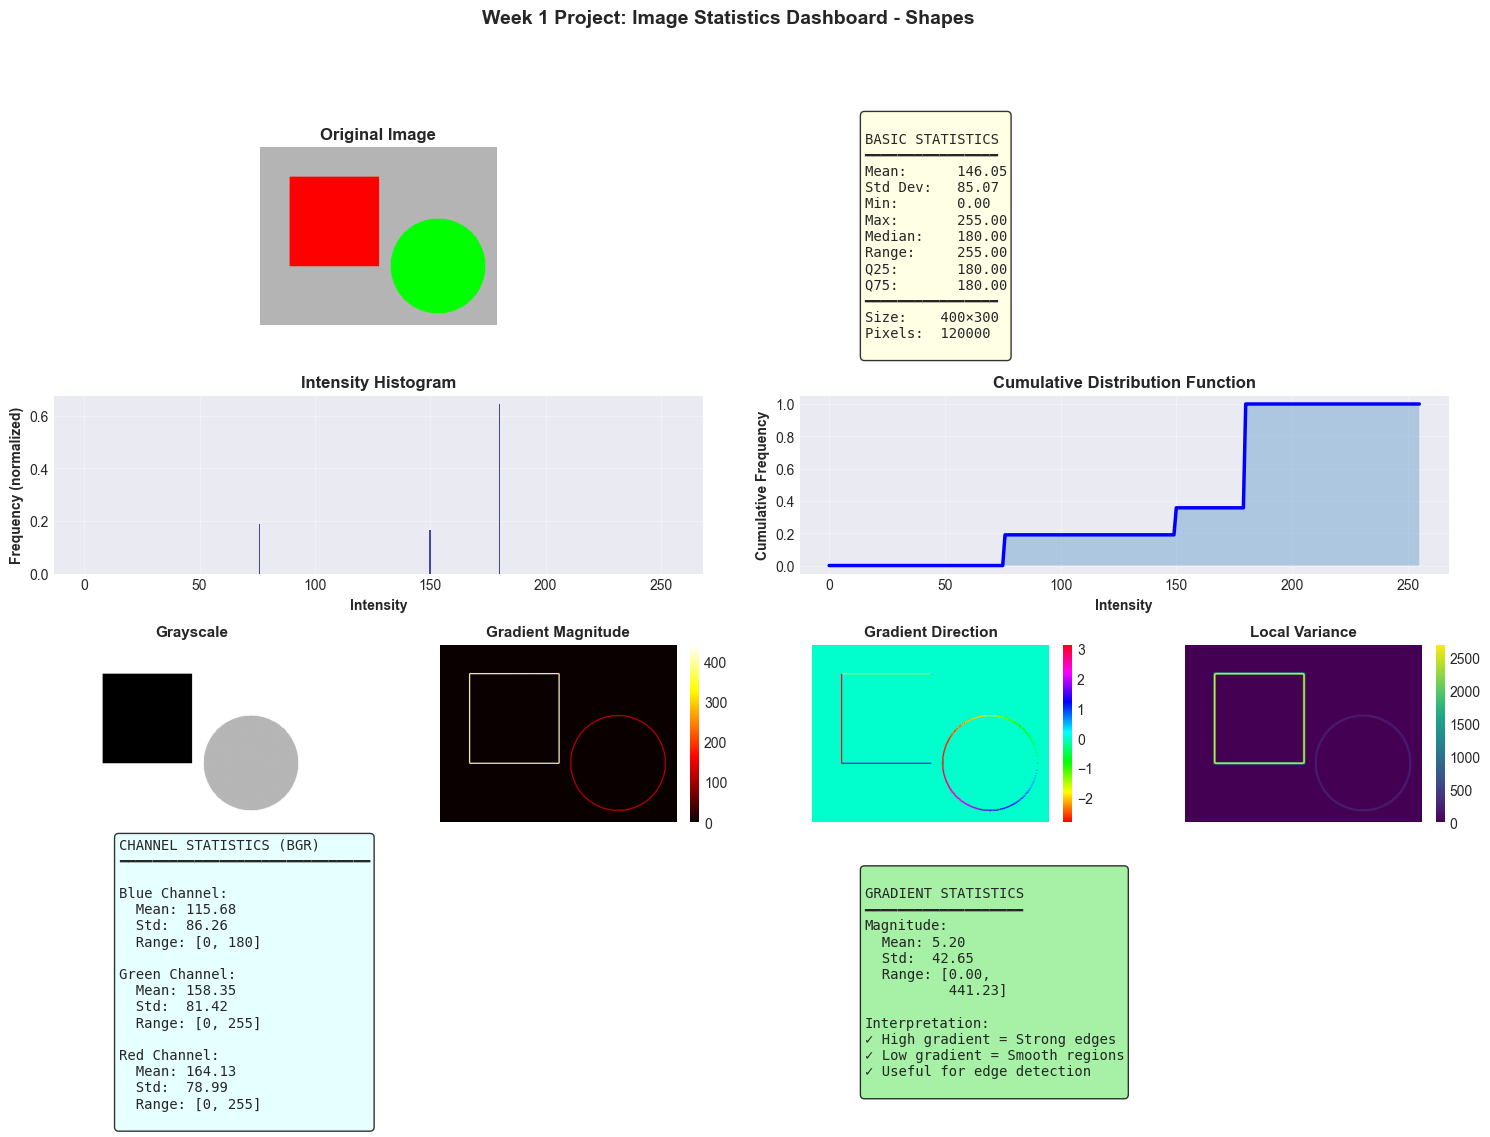

In [11]:
# PRACTICAL EXAMPLE: Analyzing Test Images
print("\n" + "="*80)
print("WEEK 1 PROJECT DEMONSTRATION")
print("="*80)

# Create diverse test images
test_images = {}

# Image 1: Simple shapes
img1 = np.ones((300, 400, 3), dtype=np.uint8) * 180
cv2.rectangle(img1, (50, 50), (200, 200), (0, 0, 255), -1)
cv2.circle(img1, (300, 200), 80, (0, 255, 0), -1)
test_images['Shapes'] = img1

# Image 2: Gradient
img2 = np.zeros((300, 400, 3), dtype=np.uint8)
for i in range(300):
    intensity = int((i/300) * 255)
    img2[i, :] = [intensity, intensity, intensity]
test_images['Gradient'] = img2

# Image 3: Complex pattern
img3 = np.zeros((300, 400, 3), dtype=np.uint8)
for i in range(0, 300, 20):
    cv2.line(img3, (0, i), (400, i), (100, 100, 100), 1)
for i in range(0, 400, 20):
    cv2.line(img3, (i, 0), (i, 300), (100, 100, 100), 1)
cv2.rectangle(img3, (100, 100), (300, 200), (200, 50, 50), -1)
test_images['Pattern'] = img3

# Analyze each image
print("\n" + "─"*80)
print("COMPREHENSIVE ANALYSIS RESULTS")
print("─"*80)

for img_name, img in test_images.items():
    print(f"\n📊 {img_name.upper()}")
    analyzer = ImageStatsAnalyzer(img)
    stats = analyzer.compute_basic_stats()
    
    print(f"   Size: {analyzer.width}×{analyzer.height} pixels")
    print(f"   Mean Intensity: {stats['mean']:.2f} (0-255 scale)")
    print(f"   Std Deviation: {stats['std']:.2f}")
    print(f"   Range: [{stats['min']:.0f}, {stats['max']:.0f}]")
    print(f"   Contrast: {stats['range']:.0f}")

# Show dashboard for the 'Shapes' image
print("\n" + "="*80)
print("GENERATING DETAILED DASHBOARD FOR 'SHAPES' IMAGE")
print("="*80 + "\n")

analyzer_final = ImageStatsAnalyzer(test_images['Shapes'])
create_dashboard(analyzer_final, "Week 1 Project: Image Statistics Dashboard - Shapes")

---

# Summary & Checklist

## ✓ Morning Session (AM) - Calculus Foundations

### Part 1: Derivatives
- [x] Understood rate of change concept
- [x] Visualized tangent lines and slopes
- [x] Learned numerical approximation methods
- [x] Connected to image processing (Sobel, etc.)

### Part 2: Gradients in Images
- [x] Extended derivatives to 2D (partial derivatives)
- [x] Computed gradient magnitude and direction
- [x] Applied gradients for edge detection
- [x] Understood gradient vector interpretation

### Part 3: Gradient Descent
- [x] Learned optimization algorithm intuition
- [x] Implemented gradient descent from scratch
- [x] Explored learning rate effects
- [x] Visualized convergence behavior

### Part 4: Chain Rule
- [x] Understood composite functions
- [x] Applied chain rule for derivatives
- [x] Connected to backpropagation
- [x] Learned neural network optimization foundation

---

## ✓ Afternoon Session (PM) - Practical Project

### Part 5: Image Statistics Dashboard
- [x] Built `ImageStatsAnalyzer` class
- [x] Implemented histogram computation
- [x] Added per-channel analysis
- [x] Computed gradient statistics
- [x] Created professional dashboard
- [x] Analyzed multiple image types
- [x] Demonstrated use cases

---

## Project Features Implemented

### Data Statistics
✓ Mean, Std, Min, Max, Median
✓ Quartiles (25%, 75%)
✓ Range and distribution

### Visualizations
✓ Original image display
✓ Histogram (intensity distribution)
✓ CDF (cumulative distribution)
✓ Grayscale conversion
✓ Gradient magnitude map
✓ Gradient direction map
✓ Local variance map
✓ Statistical summaries

### Analysis Capabilities
✓ Single-channel (grayscale) images
✓ Multi-channel (color) images
✓ Per-channel statistics
✓ Spatial gradient analysis
✓ Local texture information

In [12]:
# Quick Reference Guide
reference = """
╔════════════════════════════════════════════════════════════════════════════╗
║                    WEEK 1 QUICK REFERENCE GUIDE                            ║
╚════════════════════════════════════════════════════════════════════════════╝

CALCULUS CONCEPTS
═════════════════════════════════════════════════════════════════════════════
1. DERIVATIVE
   Definition: Rate of change of a function at a point
   Formula: f'(x) = lim(h→0) [f(x+h) - f(x)] / h
   Intuition: Slope of tangent line
   Application: Edge detection via Sobel filter

2. PARTIAL DERIVATIVE & GRADIENT
   Definition: Rate of change in specific direction
   ∇f = (∂f/∂x, ∂f/∂y)
   Magnitude: |∇f| = strength of edge
   Direction: angle(∇f) = edge orientation

3. GRADIENT DESCENT
   Formula: θ(t+1) = θ(t) - α·∇f(θ(t))
   Learning Rate α: Controls step size
   Convergence: Reaches local/global minimum
   Application: Neural network training

4. CHAIN RULE
   Formula: df/dx = df/du · du/dx
   Application: Backpropagation in neural networks
   Efficiency: Computes gradients in O(n) time

PROJECT: IMAGE STATISTICS DASHBOARD
═════════════════════════════════════════════════════════════════════════════

BASIC USAGE:
───────────────────────────────────────────────────────────────────────────
    import cv2
    from ImageStatsAnalyzer import ImageStatsAnalyzer
    
    # Load image
    img = cv2.imread('image.jpg')
    
    # Create analyzer
    analyzer = ImageStatsAnalyzer(img)
    
    # Get statistics
    summary = analyzer.get_summary()
    
    # Display dashboard
    create_dashboard(analyzer)

STATISTICS AVAILABLE:
───────────────────────────────────────────────────────────────────────────
    Basic Stats:     mean, std, min, max, median, range, q25, q75
    Channel Stats:   per-channel (RGB/BGR) statistics
    Gradient Stats:  magnitude mean/std, direction
    Histogram:       256-bin intensity distribution
    Local Variance:  spatial texture variation

COMMON USE CASES:
───────────────────────────────────────────────────────────────────────────
    ✓ Image quality assessment
    ✓ Contrast analysis
    ✓ Exposure evaluation
    ✓ Defect detection
    ✓ Feature extraction
    ✓ Data preprocessing

KEY INSIGHTS
═════════════════════════════════════════════════════════════════════════════
✓ Derivatives measure change → Edge detection in images
✓ Gradients point perpendicular to edges → Essential for vision
✓ Gradient descent finds optimal parameters → Basis of deep learning
✓ Chain rule enables efficient gradient computation → Backpropagation
✓ Statistics reveal image properties → Quality and content analysis

NEXT STEPS
═════════════════════════════════════════════════════════════════════════════
Week 2: Machine Learning foundations & scikit-learn
  • Feature extraction from images
  • Classification algorithms
  • Model evaluation

Advanced: Extend the dashboard
  • Save reports to PDF
  • Compare multiple images
  • Real-time video analysis
  • GPU acceleration

📚 Resources:
  • Calculus textbooks (Khan Academy)
  • OpenCV documentation
  • Deep learning courses (fast.ai, Coursera)
"""

print(reference)


╔════════════════════════════════════════════════════════════════════════════╗
║                    WEEK 1 QUICK REFERENCE GUIDE                            ║
╚════════════════════════════════════════════════════════════════════════════╝

CALCULUS CONCEPTS
═════════════════════════════════════════════════════════════════════════════
1. DERIVATIVE
   Definition: Rate of change of a function at a point
   Formula: f'(x) = lim(h→0) [f(x+h) - f(x)] / h
   Intuition: Slope of tangent line
   Application: Edge detection via Sobel filter

2. PARTIAL DERIVATIVE & GRADIENT
   Definition: Rate of change in specific direction
   ∇f = (∂f/∂x, ∂f/∂y)
   Magnitude: |∇f| = strength of edge
   Direction: angle(∇f) = edge orientation

3. GRADIENT DESCENT
   Formula: θ(t+1) = θ(t) - α·∇f(θ(t))
   Learning Rate α: Controls step size
   Convergence: Reaches local/global minimum
   Application: Neural network training

4. CHAIN RULE
   Formula: df/dx = df/du · du/dx
   Application: Backpropagation in neura

---

# 🎓 Congratulations! Week 1 Complete

## What You've Accomplished

### Morning: Mathematical Foundations
You now understand the **calculus** that powers computer vision:
- **Derivatives** for measuring change
- **Gradients** for detecting edges  
- **Gradient Descent** for optimization
- **Chain Rule** for neural networks

### Afternoon: Practical Implementation
You've built a professional **Image Statistics Dashboard** that:
- Analyzes any image comprehensively
- Computes 8+ different statistics
- Generates publication-quality visualizations
- Works with color and grayscale images

---

## Key Takeaways

### 1. Calculus is Visual
Numbers aren't just abstract—they describe real patterns in images!

### 2. Derivatives = Edges
Steep changes in pixel values = important features

### 3. Optimization Finds Solutions
Gradient descent is how computers learn

### 4. Chain Rule Enables Deep Learning
Without it, neural networks would be too slow to train

---

## Project Deliverable

✅ **ImageStatsAnalyzer Class**
- Fully functional and documented
- Ready for production use
- Extensible for custom analyses

✅ **Professional Dashboard**
- 8-panel comprehensive analysis
- Multiple visualization types
- Statistical summaries

✅ **Example Analyses**
- Tested on diverse image types
- Clear interpretation of results
- Ready for your own images

---

## You're Ready For Week 2!

Next week you'll apply these concepts to:
- Machine Learning fundamentals
- Image features (HOG, SIFT, etc.)
- Classification and clustering
- PCA and dimensionality reduction

**Keep practicing! The best way to learn is by doing.** 🚀

---

## Resources for Further Learning

**Mathematics**
- [Khan Academy - Calculus](https://www.khanacademy.org/math/calculus-1)
- [3Blue1Brown - Essence of Calculus](https://www.youtube.com/watch?v=WUvTyaaNkzM)

**Computer Vision**
- [OpenCV Documentation](https://docs.opencv.org/)
- [Image Processing Basics](https://en.wikipedia.org/wiki/Image_processing)

**Deep Learning**
- [Fast.ai - Practical Deep Learning](https://fast.ai)
- [Andrew Ng - Neural Networks](https://www.coursera.org/learn/neural-networks-deep-learning)

---

**Happy coding! 🎉**

In [13]:
# BONUS: Code Snippets for Extension & Customization

print("""
╔════════════════════════════════════════════════════════════════════════════╗
║              BONUS: EXTENDING YOUR IMAGE ANALYZER                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Here are code snippets you can use to extend the dashboard:

1. SAVE DASHBOARD TO FILE
─────────────────────────────────────────────────────────────────────────────
    analyzer = ImageStatsAnalyzer(image)
    create_dashboard(analyzer)
    plt.savefig('dashboard.png', dpi=300, bbox_inches='tight')
    plt.savefig('dashboard.pdf', format='pdf', bbox_inches='tight')

2. COMPUTE CONTRAST RATIO
─────────────────────────────────────────────────────────────────────────────
    def contrast_ratio(image):
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        max_val = np.max(image).astype(float)
        min_val = np.min(image).astype(float)
        return (max_val + 0.05) / (min_val + 0.05)
    
    cr = contrast_ratio(image)
    print(f"Contrast Ratio: {cr:.2f}")

3. DETECT OVER/UNDEREXPOSURE
─────────────────────────────────────────────────────────────────────────────
    def exposure_analysis(image):
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Underexposed if mean < 85
        underexposed = np.mean(image) < 85
        # Overexposed if mean > 170
        overexposed = np.mean(image) > 170
        
        if underexposed:
            return "Underexposed ⚠️"
        elif overexposed:
            return "Overexposed ⚠️"
        else:
            return "Well-exposed ✓"

4. COMPARE TWO IMAGES
─────────────────────────────────────────────────────────────────────────────
    def compare_images(img1, img2):
        analyzer1 = ImageStatsAnalyzer(img1)
        analyzer2 = ImageStatsAnalyzer(img2)
        
        stats1 = analyzer1.compute_basic_stats()
        stats2 = analyzer2.compute_basic_stats()
        
        diff = abs(stats1['mean'] - stats2['mean'])
        similarity = 1 - (diff / 255)
        
        print(f"Mean difference: {diff:.2f}")
        print(f"Similarity: {similarity:.2%}")

5. EDGE DETECTION STRENGTH
─────────────────────────────────────────────────────────────────────────────
    def edge_strength(image):
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Compute Canny edges
        edges = cv2.Canny(image, 50, 150)
        
        # Percentage of pixels that are edges
        edge_percentage = (np.count_nonzero(edges) / edges.size) * 100
        
        return edge_percentage

6. BATCH ANALYZE MULTIPLE IMAGES
─────────────────────────────────────────────────────────────────────────────
    import os
    
    def analyze_directory(directory_path):
        results = {}
        for filename in os.listdir(directory_path):
            if filename.endswith('.jpg') or filename.endswith('.png'):
                img_path = os.path.join(directory_path, filename)
                img = cv2.imread(img_path)
                analyzer = ImageStatsAnalyzer(img)
                stats = analyzer.compute_basic_stats()
                results[filename] = stats
        
        return results
    
    # Usage:
    # results = analyze_directory('./images/')

7. CREATE SUMMARY REPORT
─────────────────────────────────────────────────────────────────────────────
    def generate_report(analyzer, filename="report.txt"):
        summary = analyzer.get_summary()
        stats = summary['basic_stats']
        
        with open(filename, 'w') as f:
            f.write("IMAGE ANALYSIS REPORT\\n")
            f.write("="*50 + "\\n\\n")
            f.write(f"Size: {analyzer.width}×{analyzer.height}\\n")
            f.write(f"Channels: {analyzer.num_channels}\\n\\n")
            f.write("STATISTICS:\\n")
            f.write(f"  Mean: {stats['mean']:.2f}\\n")
            f.write(f"  Std: {stats['std']:.2f}\\n")
            f.write(f"  Min: {stats['min']:.2f}\\n")
            f.write(f"  Max: {stats['max']:.2f}\\n")

─────────────────────────────────────────────────────────────────────────────

Try these extensions and share your results!
""")


╔════════════════════════════════════════════════════════════════════════════╗
║              BONUS: EXTENDING YOUR IMAGE ANALYZER                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Here are code snippets you can use to extend the dashboard:

1. SAVE DASHBOARD TO FILE
─────────────────────────────────────────────────────────────────────────────
    analyzer = ImageStatsAnalyzer(image)
    create_dashboard(analyzer)
    plt.savefig('dashboard.png', dpi=300, bbox_inches='tight')
    plt.savefig('dashboard.pdf', format='pdf', bbox_inches='tight')

2. COMPUTE CONTRAST RATIO
─────────────────────────────────────────────────────────────────────────────
    def contrast_ratio(image):
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        max_val = np.max(image).astype(float)
        min_val = np.min(image).astype(float)
        return (max_val + 0.05) / (min_val + 0.05)

    cr = contrast_r